In [1]:
# RUN IMPORT LIBRARIES
############################################################################################
import numpy as np
import scipy
import matplotlib.pyplot as plt
import os
import tifffile as tiff
# from PIL import Image
import h5py
from matplotlib.patches import Rectangle
from scipy.optimize import curve_fit
from skimage.feature import peak_local_max
import pandas as pd


import brighteyes_ism.analysis.Graph_lib as gra

import scipy as sc

# from scipy.ndimage import fourier_shift, shift 
from os import path
import plotly.express as px
from time import time

In [2]:
file = 'Qdots_32x32_2e5um_60x_24mW_770nm_600frame_1msPixel.tif' 

# Qdots_FOV5um_64x64_5msPixel_23rip_37mW.tif    #0-22 range of z, then stopped
# Qdots_FOV5um_64x64_10msPixel_10rip_37mW.tif
# Qdots_FOV5um_64x64_100msPixel_1rip_37mW.tif
# Qdots_32x32_2e5um_60x_24mW_770nm_600frame_1msPixel
# Qdots_64x64_4um_60x_24mW_770nm_600frame_1msPixel

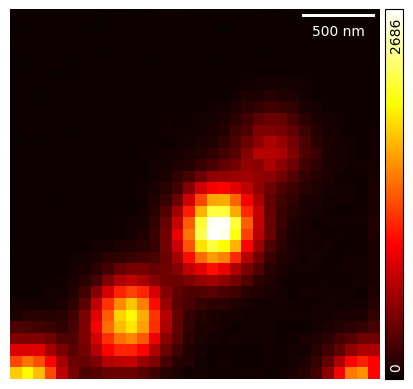

In [3]:
# RUN INPUT
#############################################################################################

#############################################################################################
# FILE IMPORT AND SETUP
############################################################################################

dir = os.getcwd()
filename = path.join(dir,'images','2025 07 07-08 Qdots',file) # input
savename = path.join(dir,'images','output',file) # output
savenameSOFI = path.join(dir,'images','output','SOFI',file)

timeSwitch = True #True if i saved the timetraces
spadFormat=7
Nspad = spadFormat**2

index7=[i for i in range(49) if i != 12]
index5=[8,9,10,11,15,16,17,18,19,22,23,24,25,26,29,30,31,32,33,36,37,38,39,40] #Check if 12 is included or not
index3=[16,17,18,23,24,25,30,31,32]
index1=[17,23,24,25,31]

# Read the TIFF stack
IMAGE_STACK = tiff.imread(filename) # (z, x, y)
IMAGE_STACK = IMAGE_STACK.astype(np.float64)

if file == 'Qdots_FOV5um_64x64_5msPixel_23rip_37mW.tif':
    IMAGE_STACK = IMAGE_STACK[0:23,:,:]  # Select frames 0-22


pxsizex = 2.5/32

# print(IMAGE_STACK.shape)
gra.ShowImg(IMAGE_STACK.sum(axis=0),cmap='hot',colorbar=True, pxsize_x=pxsizex,vmin=0)
#plt.imshow(data.std(axis=0),cmap='hot')
plt.show()

In [4]:

# for i in range(IMAGE_STACK.shape[0]):
#     plt.figure(figsize=(3, 3))
#     gra.ShowImg(IMAGE_STACK[i,:,:],cmap='hot',colorbar=False, pxsize_x=pxsizex)
#     # plt.colorbar()
#     plt.show()

In [5]:
# print(IMAGE_STACK.sum(axis=(1,2)).shape)
# print(IMAGE_STACK.mean(axis=0).sum(axis=(0,1)))
# plt.show()

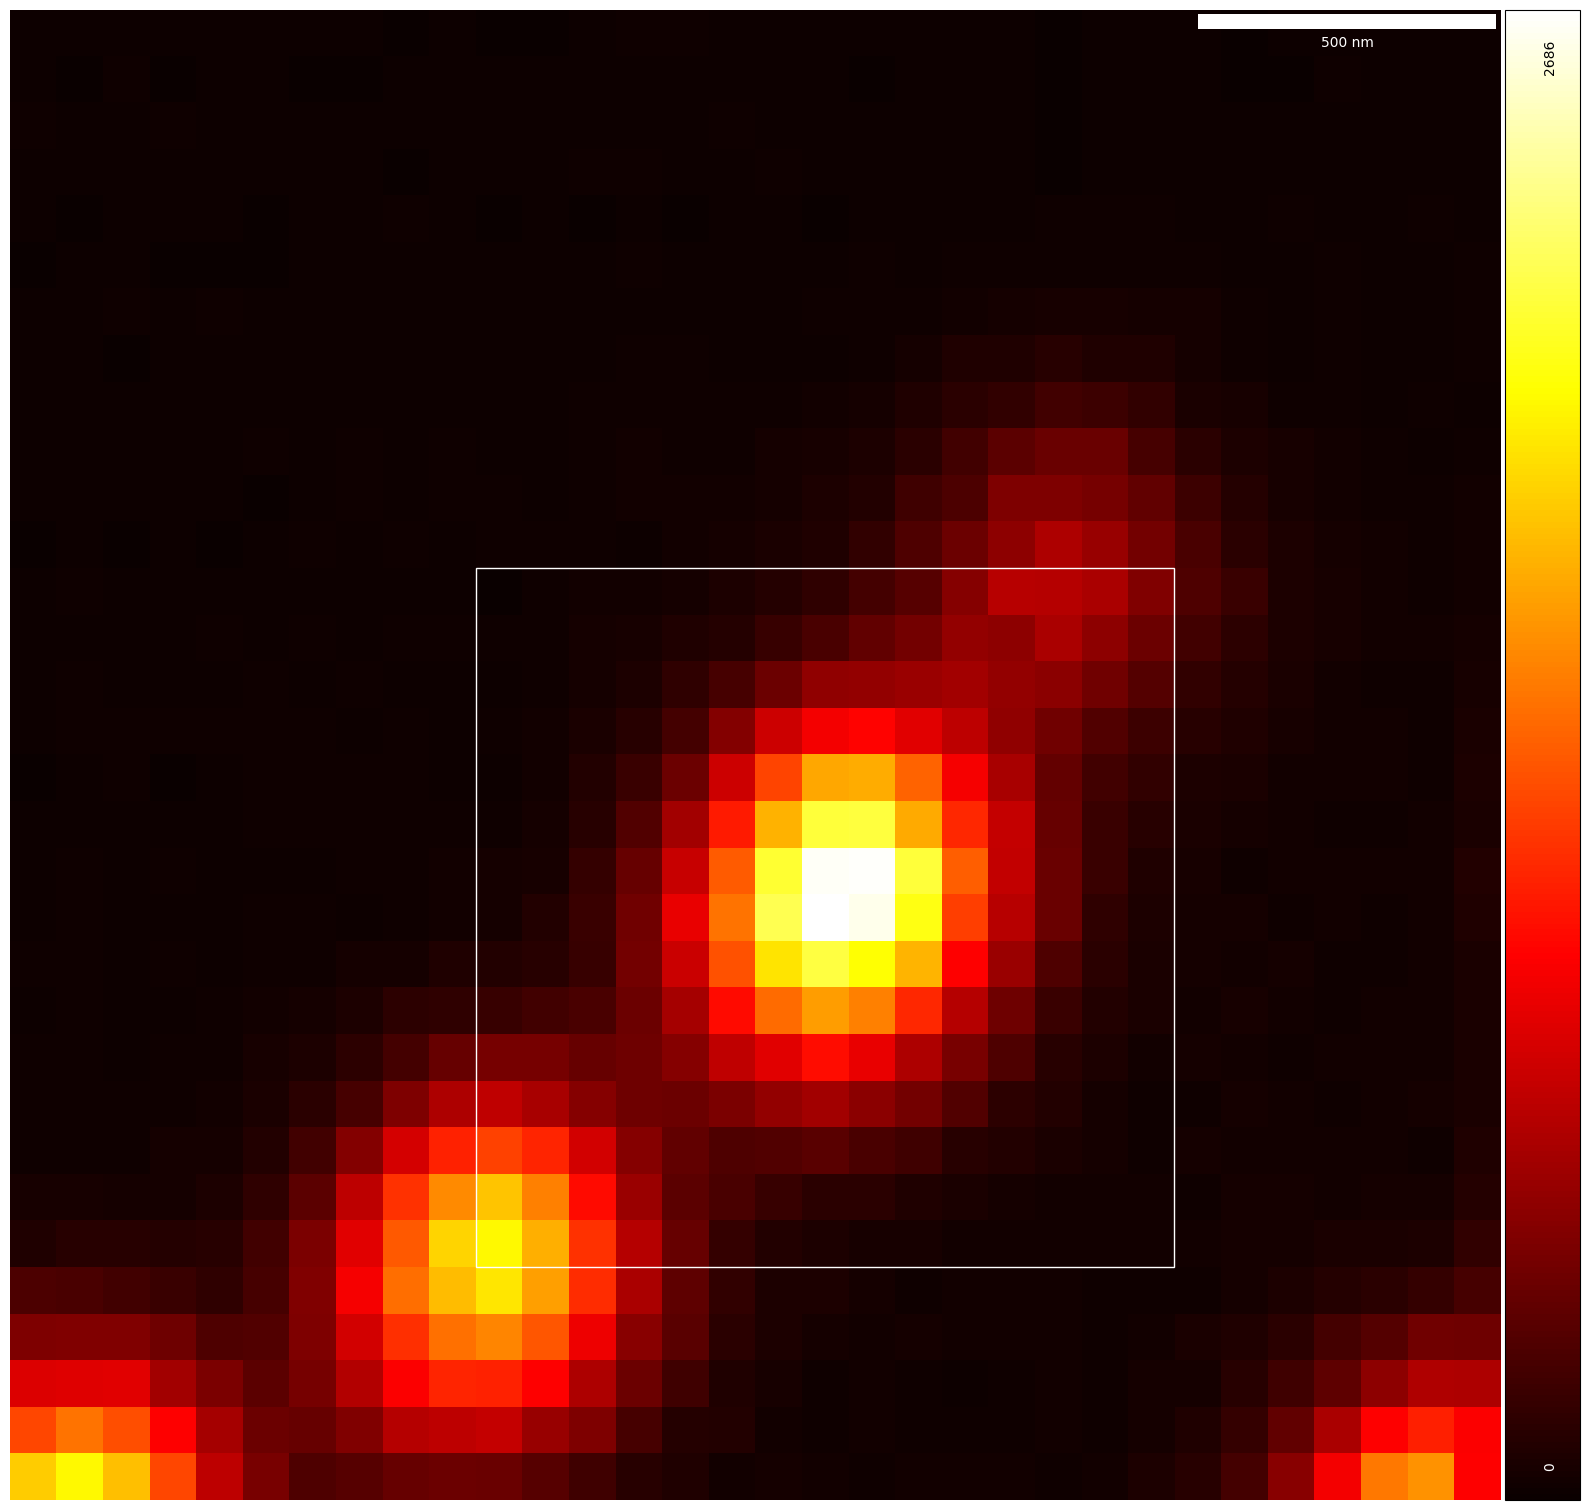

c:\Users\jocar\Desktop\tesi\images\2025 07 07-08 Qdots\Qdots_32x32_2e5um_60x_24mW_770nm_600frame_1msPixel.tif


In [6]:
# find peaks

img_STACK = IMAGE_STACK.sum(axis=0)

ROIsizeC = 15 # size of the ROI box
radius = ROIsizeC//2
signal_thresh_STACK = np.mean(img_STACK)


xc_STACK=peak_local_max(img_STACK,min_distance=radius, threshold_abs=signal_thresh_STACK) # cordinates peaks
# maxvalues = np.array([img_SPAD[xc_SPAD[i,0],xc_SPAD[i,1]] for i in range(xc_SPAD.shape[0])])

# if xc_SPAD.shape != xc_D1.shape:
#     raise "xc_D1 != xc_SPAD ha trovato più elementi in uno dei due"

Npart1 = xc_STACK.shape[0]
images = [img_STACK]

fig, axes = plt.subplots(1, len(images), figsize=(16*len(images), 16))

coords = [xc_STACK]
nparts = [Npart1]
titles = ['Confocal']

axes = [axes]
for i in range(len(images)):
    ax = axes[i]
    gra.ShowImg(images[i], ax=ax, fig=fig, cmap='hot', colorbar=True, vmin=0, pxsize_x=pxsizex)
    # ax.imshow(images[i], cmap='hot')
    #ax.set_title(titles[i])
    for l in range(nparts[i]):
        rect = Rectangle((coords[i][l,1]-ROIsizeC/2, coords[i][l,0]-ROIsizeC/2), ROIsizeC, ROIsizeC, linewidth=1, edgecolor='w', facecolor='none')
        ax.add_patch(rect)
        #ax.text(coords[i][l,1]-radius, coords[i][l,0]-radius+1, l, fontsize=14, color='white')
plt.tight_layout()
plt.show()

print(filename)

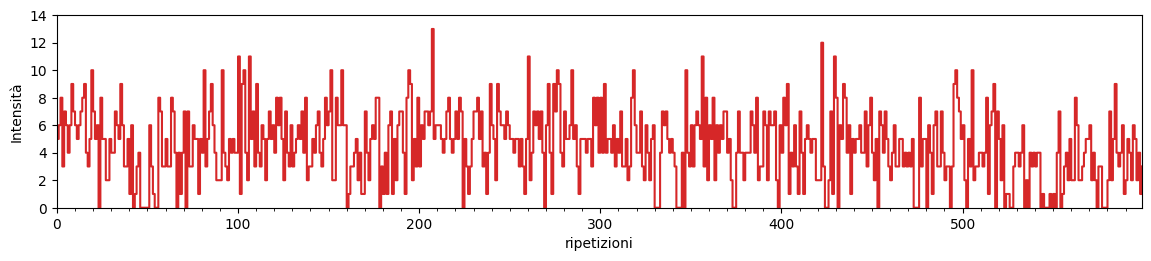

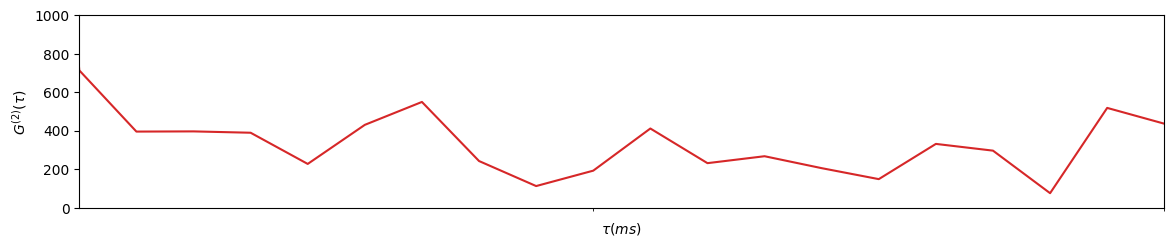

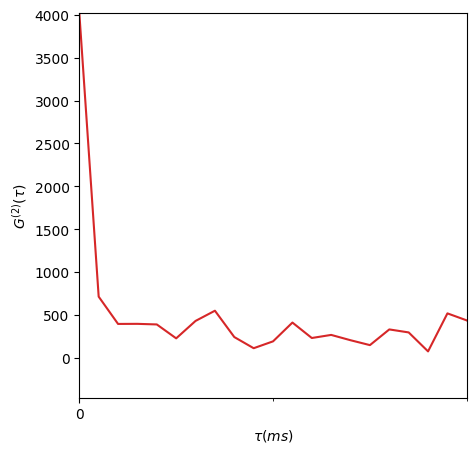

In [23]:
points = np.array([(19,17),(19,18),(18,17),(18,18),(26,10),(12,22)])
# plt.imshow(img_STACK, cmap='hot')
# plt.scatter(points[:, 1], points[:, 0], c='cyan', s=100, marker='x')
# plt.title('Detected Peaks')
# plt.colorbar()
# plt.show()
points = np.array([(19,17)])
plt.figure(figsize=(14, 2.5))
for (y,x) in points:
    plt.step(np.arange(0,600),IMAGE_STACK[:,y,x],where='post',color='tab:red')
plt.xlabel('ripetizioni')
plt.ylabel('Intensità')
plt.xticks(np.arange(0,610,10), minor=True)
plt.xticks(np.arange(0,700,100), labels=[str(i) for i in np.arange(0,700,100)])
plt.margins(x=0, y=0)
plt.yticks(np.arange(0,15,2))
plt.show()

def correlazione(signal):
    t = signal - np.mean(signal)
    N = len(t)
    fft_t = np.fft.fft(t)
    crosscorr = np.real(np.fft.ifft(fft_t * np.conjugate(fft_t)))
    # crosscorr = np.fft.fftshift(crosscorr)  # opzionale: centra lo zero
    return crosscorr #/ (N * np.var(t))

plt.figure(figsize=(14, 2.5))
for (y,x) in points:
    plt.plot(correlazione(IMAGE_STACK[:,y,x]),label=f'({y},{x})', color='tab:red')

plt.xticks(np.arange(0,610,10), minor=True)
plt.xticks(np.arange(0,700,100), labels=[str(i) for i in np.arange(0,700,100)])
plt.xlabel('$\\tau (ms)$')
plt.ylabel('$G^{(2)}(\\tau)$')
plt.xlim(1,20)
plt.ylim(0,1000)
# plt.legend()
plt.show()


plt.figure(figsize=(5, 5))
for (y,x) in points:
    plt.plot(correlazione(IMAGE_STACK[:,y,x]),label=f'({y},{x})', color='tab:red')

plt.xticks(np.arange(0,610,10), minor=True)
plt.xticks(np.arange(0,700,100), labels=[str(i) for i in np.arange(0,700,100)])
plt.xlabel('$\\tau (ms)$')
plt.ylabel('$G^{(2)}(\\tau)$')
#plt.yticks(np.arange(0,1,0.2))
plt.xlim(0,20)
plt.margins(x=0, y=0)
#plt.ylim(0,1)
# plt.xlim(0,20)
# plt.legend()
plt.show()


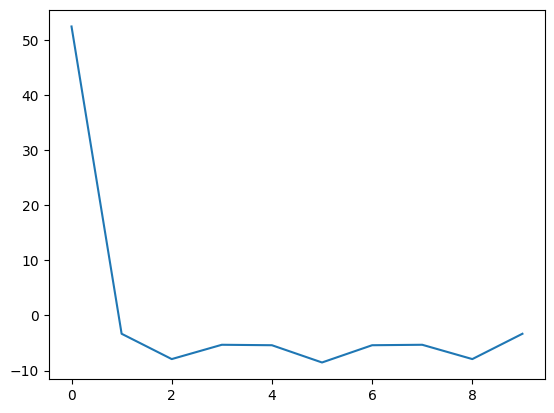

In [8]:
t = IMAGE_STACK[:,19,17]
t_split = np.reshape(t,(60,10))


def corr(a):
    a = a-np.mean(a)
    b = np.zeros_like(a)
    c = np.concatenate([a,a])
    for i in range(len(a)):
        b[i] = np.sum(a*c[i:i+len(a)])
    return b

correlated = np.mean([corr(t_split[i]) for i in range(t_split.shape[0])], axis=0)
plt.plot(correlated)

plt.show()

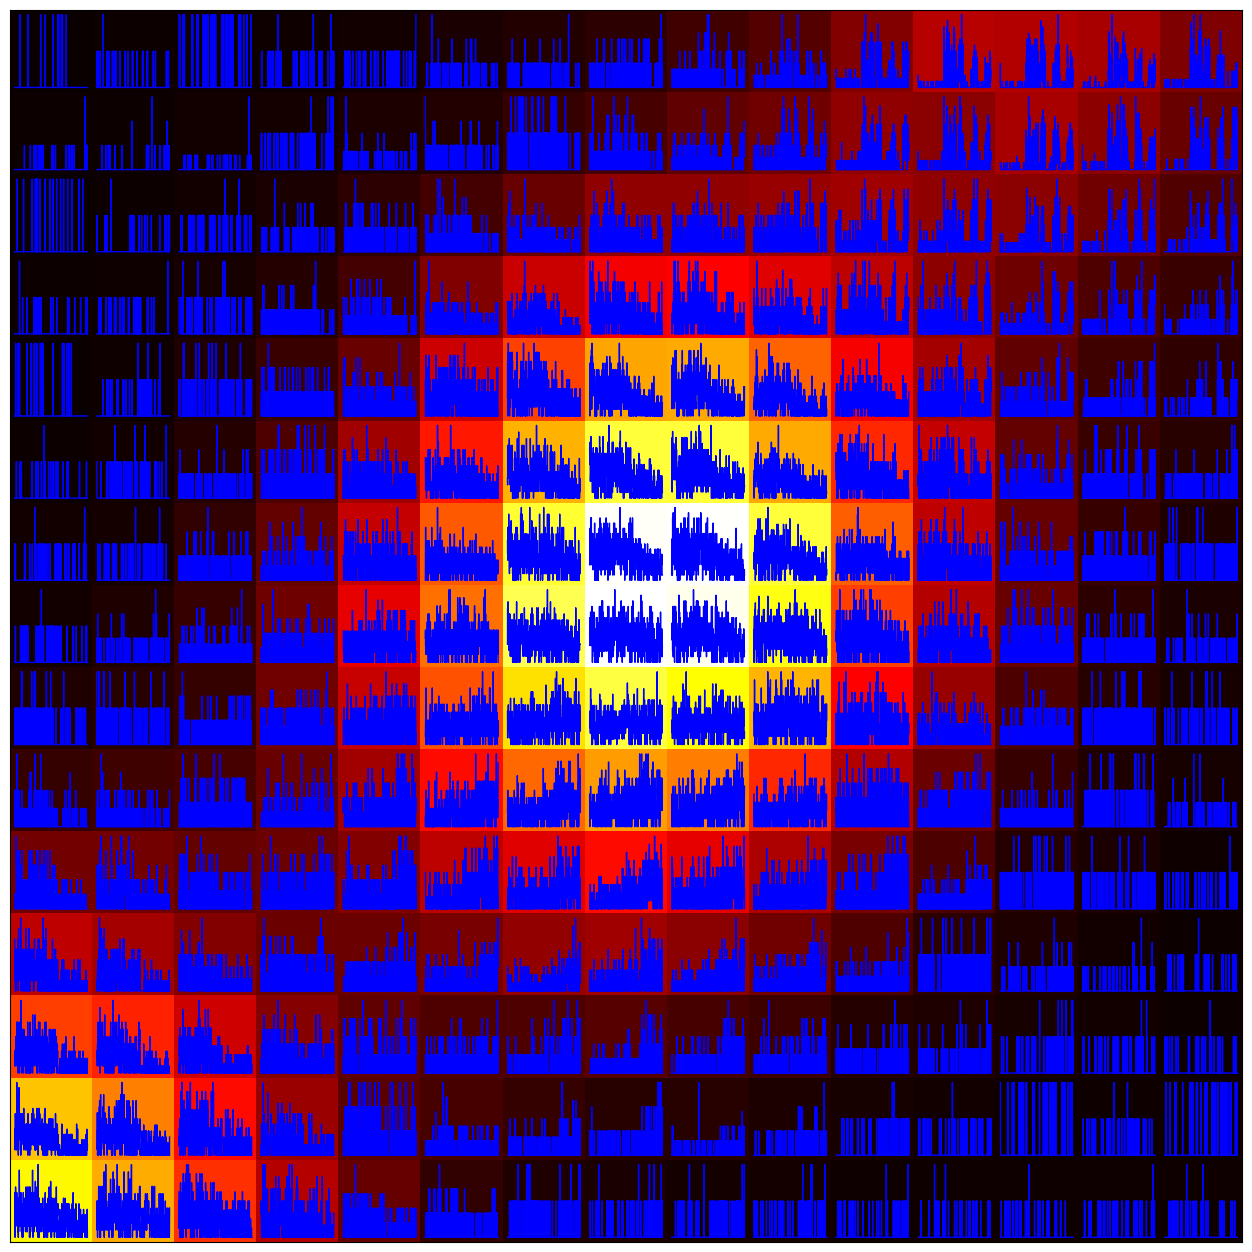

In [9]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

ROI_0 = IMAGE_STACK[:, xc_STACK[0,0]-ROIsizeC//2:xc_STACK[0,0]+ROIsizeC//2+1, xc_STACK[0,1]-ROIsizeC//2:xc_STACK[0,1]+ROIsizeC//2+1].astype(np.float64)
# ROI_1 = IMAGE_STACK[:, xc_STACK[1,0]-ROIsizeC//2:xc_STACK[1,0]+ROIsizeC//2+1, xc_STACK[1,1]-ROIsizeC//2:xc_STACK[1,1]+ROIsizeC//2+1]
# ROI_2 = IMAGE_STACK[:, xc_STACK[2,0]-ROIsizeC//2:xc_STACK[2,0]+ROIsizeC//2+1, xc_STACK[2,1]-ROIsizeC//2:xc_STACK[2,1]+ROIsizeC//2+1]
# ROI_3 = IMAGE_STACK[:, xc_STACK[3,0]-ROIsizeC//2:xc_STACK[3,0]+ROIsizeC//2+1, xc_STACK[3,1]-ROIsizeC//2:xc_STACK[3,1]+ROIsizeC//2+1]
# ROI_4 = IMAGE_STACK[:, xc_STACK[4,0]-ROIsizeC//2:xc_STACK[4,0]+ROIsizeC//2+1, xc_STACK[4,1]-ROIsizeC//2:xc_STACK[4,1]+ROIsizeC//2+1]

fig, axes = plt.subplots(1, Npart1, figsize=(16*Npart1, 16))
for idx in range(1): #Npart1):
    ROI = locals()[f'ROI_{idx}']
    ax = axes[idx] if Npart1 > 1 else axes
    im = ax.imshow(ROI.sum(axis=0), cmap='hot')
    # ax.set_title(f'ROI_{idx}',fontsize=20)
    ax.set_xticks([])
    ax.set_yticks([])
    n_z, n_pixels_y, n_pixels_x = ROI.shape
    for i in range(n_pixels_y):
        for j in range(n_pixels_x):
            axins = inset_axes(ax,
                               width=0.80, height=0.80,
                               loc='center',
                               bbox_to_anchor=(j + 0.5 - 1, i + 0.5 - 1, 1, 1),
                               bbox_transform=ax.transData,
                               borderpad=0)
            x = np.arange(0, n_z, 1)
            y = ROI[:, i, j]
            axins.plot(x, y, color='blue', linewidth=1)
            axins.set_facecolor('none')
            axins.axis('off')
plt.show()


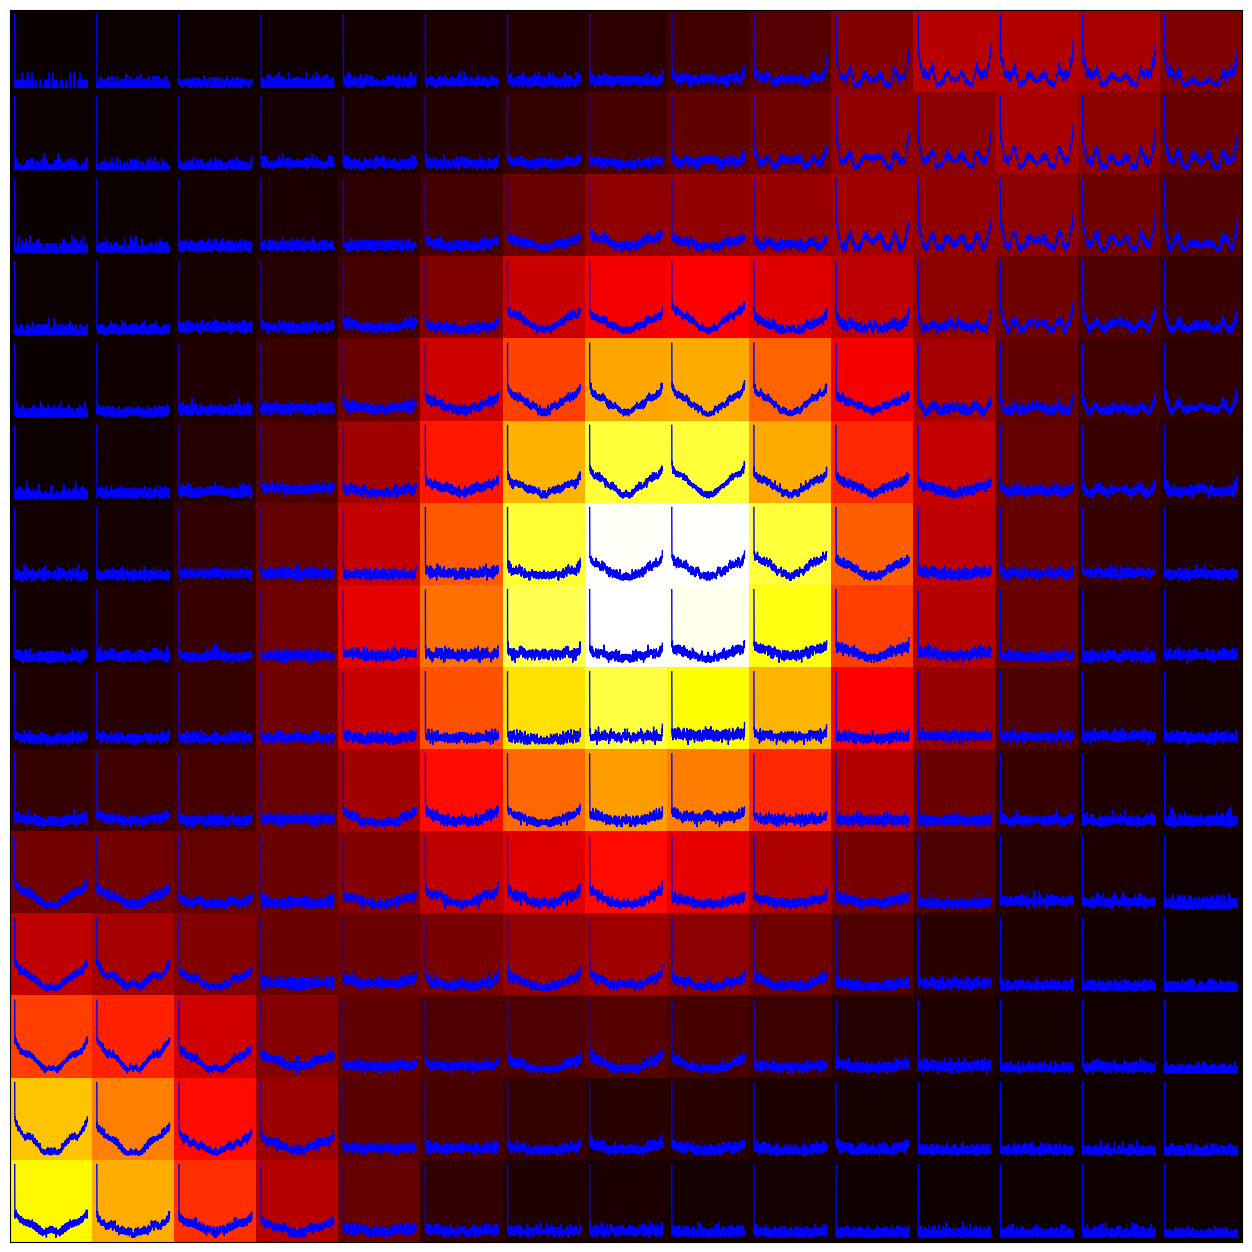

In [10]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, axes = plt.subplots(1, Npart1, figsize=(16*Npart1, 16))
for roi_idx in range(1): # Npart1):
    ROI = locals()[f'ROI_{roi_idx}']
    ax = axes[roi_idx] if Npart1 > 1 else axes
    im = ax.imshow(ROI.sum(axis=0), cmap='hot')
    # ax.set_title(f'ROI_{roi_idx} $g(\\tau)^2$',fontsize=20)
    ax.set_xticks([])
    ax.set_yticks([])

    # def correlazione(signal):
    #     t = signal - np.mean(signal)
    #     fft_t = np.fft.fft(t)
    #     fft_t_c = np.conjugate(fft_t)
    #     crosscorr = np.real(np.fft.ifft(fft_t * fft_t_c))
    #     return crosscorr

    def correlazione(signal):
        t = signal - np.mean(signal)
        N = len(t)
        fft_t = np.fft.fft(t)
        crosscorr = np.real(np.fft.ifft(fft_t * np.conjugate(fft_t)))
        # crosscorr = np.fft.fftshift(crosscorr)  # opzionale: centra lo zero
        return crosscorr

    ROI_correlated = ROI.copy()
    n_z, n_pixels_y, n_pixels_x = ROI.shape

    for i in range(n_pixels_y):
        for j in range(n_pixels_x):
            ROI_correlated[:, i, j] = correlazione(ROI[:, i, j])

    # print(f"ROI_{roi_idx}_correlated shape:", ROI_correlated.shape)

    for i in range(n_pixels_y):
        for j in range(n_pixels_x):
            axins = inset_axes(ax,
                               width=0.80, height=0.80,
                               loc='center',
                               bbox_to_anchor=(j + 0.5 - 1, i + 0.5 - 1, 1, 1),
                               bbox_transform=ax.transData,
                               borderpad=0)
            x = np.arange(0, n_z, 1)
            y = ROI_correlated[:, i, j]
            axins.plot(x, y, color='blue', linewidth=1)
            axins.set_facecolor('none')
            axins.axis('off')

plt.show()

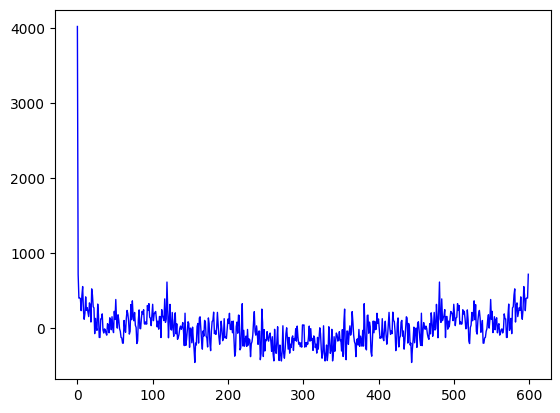

In [11]:
plt.plot(ROI_correlated[:,7,7], color='blue', linewidth=1)

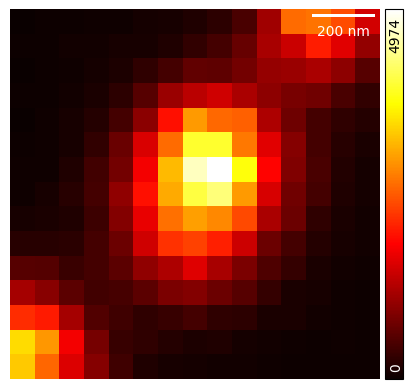

In [12]:
# plt.plot(ROI_correlated.sum(axis=(1,2)), color='blue', linewidth=2)
# # plt.yscale('log')
# plt.xlim(0, 100)
# plt.show()

im = ROI_correlated[0,:,:]
gra.ShowImg(im,cmap='hot',colorbar=True, pxsize_x=pxsizex,vmin=0)
plt.show()

In [13]:
print(IMAGE_STACK.shape)

(600, 32, 32)


C:\Users\jocar\AppData\Local\Temp\ipykernel_16552\632804448.py:18: RuntimeWarning: overflow encountered in exp
  popt,pcov = sc.optimize.curve_fit(lambda t, τ, A, B: A*np.exp(-t/τ) + B, np.arange(0,100), IMAGE_SOFI[:, i, j][0:100], p0=(10, 1000, 100), maxfev=10000)
C:\Users\jocar\AppData\Local\Temp\ipykernel_16552\632804448.py:18: RuntimeWarning: overflow encountered in multiply
  popt,pcov = sc.optimize.curve_fit(lambda t, τ, A, B: A*np.exp(-t/τ) + B, np.arange(0,100), IMAGE_SOFI[:, i, j][0:100], p0=(10, 1000, 100), maxfev=10000)
C:\Users\jocar\AppData\Local\Temp\ipykernel_16552\632804448.py:18: OptimizeWarning: Covariance of the parameters could not be estimated
  popt,pcov = sc.optimize.curve_fit(lambda t, τ, A, B: A*np.exp(-t/τ) + B, np.arange(0,100), IMAGE_SOFI[:, i, j][0:100], p0=(10, 1000, 100), maxfev=10000)


(600, 32, 32)


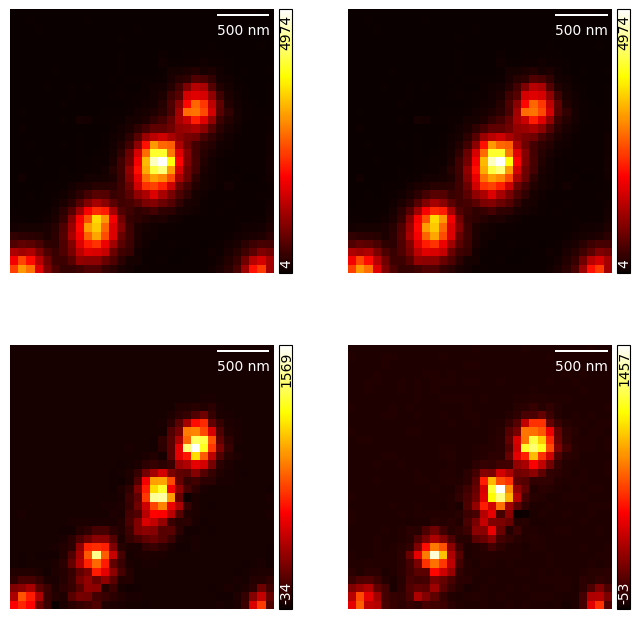

In [14]:
# IMAGE STACK VS IMAGE SOFI
def correlazione(signal):
    t = signal - np.mean(signal)
    N = len(t)
    fft_t = np.fft.fft(t)
    crosscorr = np.real(np.fft.ifft(fft_t * np.conjugate(fft_t)))
    # crosscorr = np.fft.fftshift(crosscorr)  # opzionale: centra lo zero
    return crosscorr

IMAGE_SOFI = np.zeros_like(IMAGE_STACK)

taus = np.zeros(IMAGE_STACK.shape[0])

for i in range(IMAGE_STACK.shape[1]):
    for j in range(IMAGE_STACK.shape[2]):
        IMAGE_SOFI[:, i, j] = correlazione(IMAGE_STACK[:, i, j])
        try:
            popt,pcov = sc.optimize.curve_fit(lambda t, τ, A, B: A*np.exp(-t/τ) + B, np.arange(0,100), IMAGE_SOFI[:, i, j][0:100], p0=(10, 1000, 100), maxfev=10000)
        except:
            popt = [np.nan, np.nan, np.nan]
        taus[i] = popt[0]

fig, axs = plt.subplots(2, 2, figsize=(8, 8))


IMAGE_CONF = IMAGE_STACK - np.mean(IMAGE_STACK, axis=0)
print(IMAGE_CONF.shape)
gra.ShowImg((IMAGE_CONF*IMAGE_CONF).sum(axis=0), fig=fig, ax=axs[0, 0], cmap='hot', colorbar=True, pxsize_x=pxsizex)
#axs[0, 0].set_title('IMAGE_STACK[0]')
axs[0, 0].axis('off')

gra.ShowImg(IMAGE_SOFI[0, :, :], fig=fig, ax=axs[0, 1], cmap='hot', colorbar=True, pxsize_x=pxsizex)
#axs[0, 1].set_title('IMAGE_SOFI[0]')
axs[0, 1].axis('off')

gra.ShowImg(IMAGE_SOFI[1, :, :], fig=fig, ax=axs[1, 0], cmap='hot', colorbar=True, pxsize_x=pxsizex)
#axs[1, 0].set_title('IMAGE_SOFI[1]')
axs[1, 0].axis('off')

gra.ShowImg(IMAGE_SOFI[2, :, :], fig=fig, ax=axs[1, 1], cmap='hot', colorbar=True, pxsize_x=pxsizex)
#axs[1, 1].set_title('IMAGE_SOFI[2]')
axs[1, 1].axis('off')

# plt.tight_layout()
plt.show()


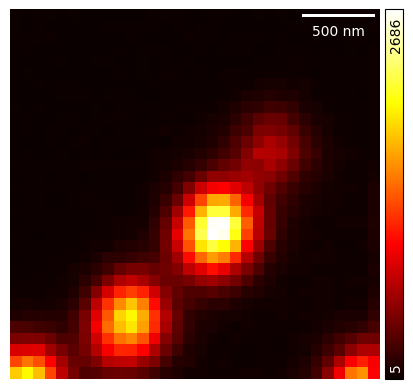

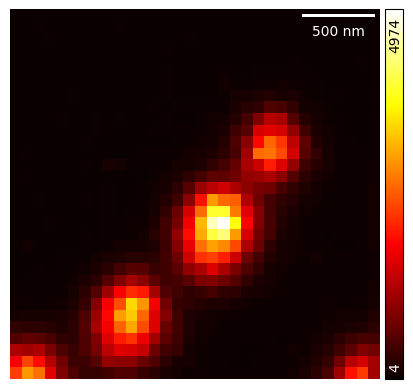

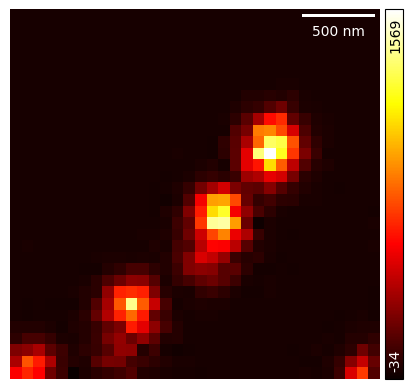

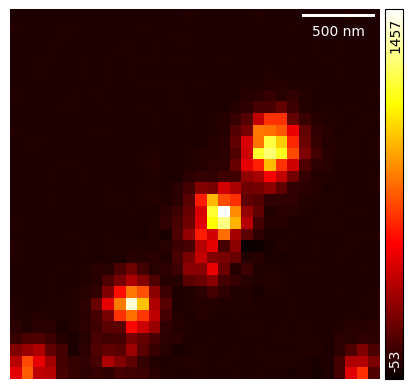

In [15]:
gra.ShowImg(IMAGE_STACK.sum(axis=0), cmap='hot', colorbar=True, pxsize_x=pxsizex)
plt.show()
#axs[0, 0].set_title('IMAGE_STACK[0]')
#axs[0, 0].axis('off')

gra.ShowImg(IMAGE_SOFI[0, :, :], cmap='hot', colorbar=True, pxsize_x=pxsizex)
plt.show()
#axs[0, 1].set_title('IMAGE_SOFI[0]')
#axs[0, 1].axis('off')

gra.ShowImg(IMAGE_SOFI[1, :, :], cmap='hot', colorbar=True, pxsize_x=pxsizex)
plt.show()
#axs[1, 0].set_title('IMAGE_SOFI[1]')
#axs[1, 0].axis('off')

gra.ShowImg(IMAGE_SOFI[2, :, :], cmap='hot', colorbar=True, pxsize_x=pxsizex)
#axs[1, 1].set_title('IMAGE_SOFI[2]')
#axs[1, 1].axis('off')

# plt.tight_layout()
plt.show()

100.00000000000001


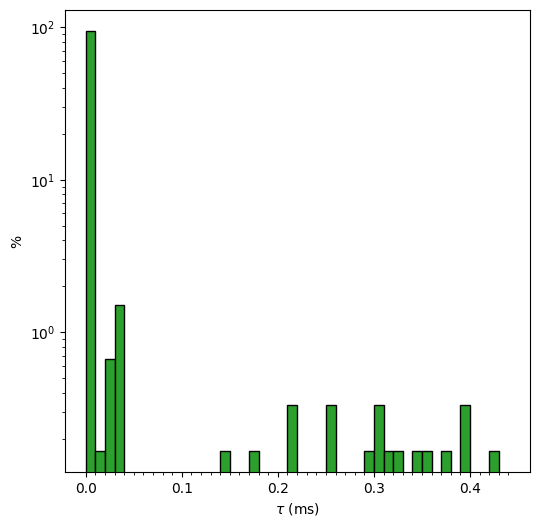

In [16]:
plt.figure(figsize=(6, 6))
h = plt.hist(taus, bins=np.arange(0, 0.45, 0.01),edgecolor='black', color='tab:green',align='mid',density=True, stacked=True)
plt.yscale('log')
print(np.sum(h[0]))
plt.xlabel('$\\tau$ (ms)')
plt.xticks(np.arange(0, 0.45, 0.01), minor=True)

plt.ylabel('%')
# plt.title('Tau Values Histogram')
plt.show()

In [17]:
CONF = IMAGE_STACK.sum(axis=0)
SOFI_0 = IMAGE_SOFI[0,:,:]
SOFI_1 = IMAGE_SOFI[1,:,:]
SOFI_2 = IMAGE_SOFI[2,:,:]

ROIsizeC = 8 # size of the ROI box
radius = ROIsizeC//2
signal_thresh_CONF = np.mean(CONF)
signal_thresh_SOFI_0 = np.mean(SOFI_0)
signal_thresh_SOFI_1 = np.mean(SOFI_1)
signal_thresh_SOFI_2 = np.mean(SOFI_2)

xc_CONF=peak_local_max(CONF,min_distance=radius, threshold_abs=signal_thresh_CONF) 
xc_SOFI_0=peak_local_max(SOFI_0,min_distance=radius, threshold_abs=signal_thresh_SOFI_0)
xc_SOFI_1=peak_local_max(SOFI_1,min_distance=radius, threshold_abs=signal_thresh_SOFI_1)
xc_SOFI_2=peak_local_max(SOFI_2,min_distance=radius, threshold_abs=signal_thresh_SOFI_2)

xc_CONF = np.array([xc_CONF[0], xc_CONF[1],xc_SOFI_0[2]])
xc_SOFI_0 = np.array([xc_SOFI_0[0], xc_SOFI_0[1],xc_SOFI_0[2]])
xc_SOFI_1 = np.array([xc_SOFI_1[1], xc_SOFI_1[2],xc_SOFI_1[0]])
xc_SOFI_2 = np.array([xc_SOFI_2[0], xc_SOFI_2[1],xc_SOFI_2[2]])

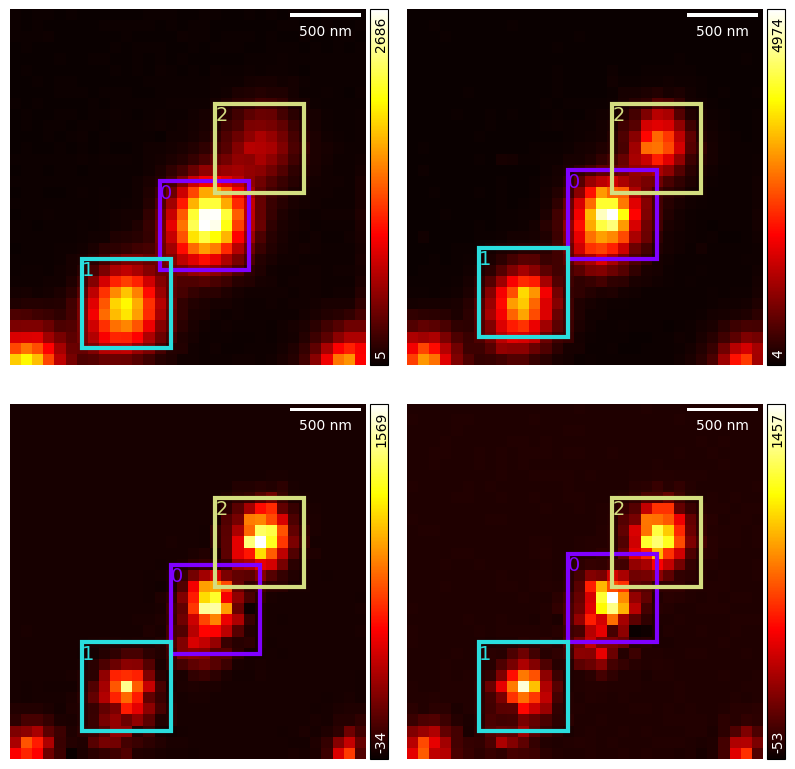

In [18]:
from matplotlib import cm
colors = [cm.rainbow(i / 3) for i in range(3)]

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# images_key = ['ROI_D0', 'ROI_D1', 'ROI_D3', 'ROI_D5', 'ROI_D7', 'ROI_sum_D1', 'ROI_sum_D3', 'ROI_sum_D5', 'ROI_sum_D7']

################ CONFOCAL ################
gra.ShowImg(CONF, fig=fig, ax=axes[0,0], cmap='hot', colorbar=True, pxsize_x=pxsizex)
for i in range(xc_CONF.shape[0]):
    rect = Rectangle((xc_CONF[i,1]-ROIsizeC/2, xc_CONF[i,0]-ROIsizeC/2), ROIsizeC, ROIsizeC, linewidth=3, edgecolor=colors[i], facecolor='none')
    axes[0,0].add_patch(rect)
    axes[0,0].text(xc_CONF[i,1]-radius, xc_CONF[i,0]-radius+1.5, i, fontsize=14, color=colors[i])

################ SOFI 0 ################
gra.ShowImg(SOFI_0, fig=fig, ax=axes[0,1], cmap='hot', colorbar=True, pxsize_x=pxsizex)
for i in range(xc_SOFI_0.shape[0]):
    rect = Rectangle((xc_SOFI_0[i,1]-ROIsizeC/2, xc_SOFI_0[i,0]-ROIsizeC/2), ROIsizeC, ROIsizeC, linewidth=3, edgecolor=colors[i], facecolor='none')
    axes[0,1].add_patch(rect)
    axes[0,1].text(xc_SOFI_0[i,1]-radius, xc_SOFI_0[i,0]-radius+1.5, i, fontsize=14, color=colors[i])

################ SOFI 1 ################
gra.ShowImg(SOFI_1, fig=fig, ax=axes[1,0], cmap='hot', colorbar=True, pxsize_x=pxsizex)
for i in range(xc_SOFI_1.shape[0]):
    rect = Rectangle((xc_SOFI_1[i,1]-ROIsizeC/2, xc_SOFI_1[i,0]-ROIsizeC/2), ROIsizeC, ROIsizeC, linewidth=3, edgecolor=colors[i], facecolor='none')
    axes[1,0].add_patch(rect)
    axes[1,0].text(xc_SOFI_1[i,1]-radius, xc_SOFI_1[i,0]-radius+1.5, i, fontsize=14, color=colors[i])

################ SOFI 2 ################
gra.ShowImg(SOFI_2, fig=fig, ax=axes[1,1], cmap='hot', colorbar=True, pxsize_x=pxsizex)
for i in range(xc_SOFI_2.shape[0]):
    rect = Rectangle((xc_SOFI_2[i,1]-ROIsizeC/2, xc_SOFI_2[i,0]-ROIsizeC/2), ROIsizeC, ROIsizeC, linewidth=3, edgecolor=colors[i], facecolor='none')
    axes[1,1].add_patch(rect)
    axes[1,1].text(xc_SOFI_2[i,1]-radius, xc_SOFI_2[i,0]-radius+1.5, i, fontsize=14, color=colors[i])

plt.subplots_adjust(wspace=0.05, hspace=0.05)
plt.show()
# for pos, im_key in enumerate(images_key):
#     ax = axes[pos // 3, pos % 3]
#     im = gra.ShowImg(images[pos], pxsize_x = pxsizex, fig = fig, ax = ax, cmap='hot', colorbar=True,vmin=mincolor, vmax=maxcolor) #[422:512,45:135]
#     # im = ax.imshow(images[pos], cmap='hot', vmin=mincolor, vmax=maxcolor)
#     ax.set_title(titles[pos])
#     for l in range(len(ROI_TO_ANALYSE['ROI_D0'])):
#         i = ROI_TO_ANALYSE[im_key][l]
#         rect = Rectangle((coords[pos][i,1]-ROIsizeC/2, coords[pos][i,0]-ROIsizeC/2), ROIsizeC, ROIsizeC, linewidth=3, edgecolor=colors[l], facecolor='none')
#         ax.add_patch(rect)
#         ax.text(coords[pos][i,1]-radius, coords[pos][i,0]-radius+1.5, l, fontsize=14, color=colors[l])
#     # fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

In [19]:
bkg = np.mean(CONF[0:10,0:10])
sig = np.max(CONF)
print('SBR conf: ', sig/bkg)

bkg = np.mean(SOFI_0[0:10,0:10])
sig = np.max(SOFI_0)
print('SBR sofi 0: ', sig/bkg)

bkg = np.mean(SOFI_1[0:10,0:10])
sig = np.max(SOFI_1)
print('SBR sofi 1: ', sig/bkg)

bkg = np.mean(SOFI_2[0:10,0:10])
sig = np.max(SOFI_2)
print('SBR sofi 2: ', np.abs(sig/bkg))

SBR conf:  182.10169491525423
SBR sofi 0:  320.9204251590045
SBR sofi 1:  155698.34710743782
SBR sofi 2:  36515.90814196241


In [20]:
def gaussian_radial_fit(coord, A, x0, y0, sigma, offset):
    x, y = coord
    r2 = (x - x0)**2 + (y - y0)**2
    return A * np.exp(-r2 / (2 * sigma**2)) + offset

# popt, pcov = curve_fit(gaussian_radial_fit, coord, D5_roi.ravel(), p0=[np.max(D5_roi), halfR, halfR, 3, np.min(D5_roi)]) # fit ISM
# popt2, pcov2 = curve_fit(gaussian_radial_fit, coord, D5_sum_roi.ravel(), p0=[np.max(D5_sum_roi), halfR, halfR, 3, np.min(D5_sum_roi)]) # fit confocale
ROIsizeC = 8
Δ = ROIsizeC // 2

#ISM_DATAFRAME = pd.DataFrame() # pd.read_csv('./images/ISM/ISM_FWHM.csv')

result = []

for i in range(3):

    y,x = xc_CONF[i]
    index_ROI = i
    ROI_CONF = CONF[y-Δ:y+Δ+1, x-Δ:x+Δ+1]

    size = ROI_CONF.shape[0]
    x = np.arange(0, size)
    y = np.arange(0, size)
    X, Y = np.meshgrid(x, y)
    coord = (X.ravel(), Y.ravel())
    limits = ([0, 0, 0, -np.inf], [np.inf, size, np.inf, np.inf])

    popt_CONF, pcov_CONF = curve_fit(gaussian_radial_fit, coord, ROI_CONF.ravel(),p0=[np.max(ROI_CONF), size/2, size/2, 3, np.mean(ROI_CONF)])
    FWHM_CONF = np.round(2.355 * popt_CONF[3] * pxsizex * 1000, 0)
    sigma_FWHM_CONF = np.round(2.355 * np.sqrt(np.diag(pcov_CONF))[3] * pxsizex * 1000, 0)


    y,x = xc_SOFI_0[i]
    ROI_SOFI_0 = SOFI_0[y-Δ:y+Δ+1, x-Δ:x+Δ+1]
    popt_SOFI_0, pcov_SOFI_0 = curve_fit(gaussian_radial_fit, coord, ROI_SOFI_0.ravel(),p0=[np.max(ROI_SOFI_0), size/2, size/2, 3, np.mean(ROI_SOFI_0)])
    FWHM_SOFI_0 = np.round(2.355 * popt_SOFI_0[3] * pxsizex * 1000, 0)
    sigma_FWHM_SOFI_0 = np.round(2.355 * np.sqrt(np.diag(pcov_SOFI_0))[3] * pxsizex * 1000, 0)

    y,x = xc_SOFI_1[i]
    ROI_SOFI_1 = SOFI_1[y-Δ:y+Δ+1, x-Δ:x+Δ+1]
    popt_SOFI_1, pcov_SOFI_1 = curve_fit(gaussian_radial_fit, coord, ROI_SOFI_1.ravel(),p0=[np.max(ROI_SOFI_1), size/2, size/2, 3, np.mean(ROI_SOFI_1)])
    FWHM_SOFI_1 = np.round(2.355 * popt_SOFI_1[3] * pxsizex * 1000, 0)
    sigma_FWHM_SOFI_1 = np.round(2.355 * np.sqrt(np.diag(pcov_SOFI_1))[3] * pxsizex * 1000, 0)

    y,x = xc_SOFI_2[i]
    ROI_SOFI_2 = SOFI_2[y-Δ:y+Δ+1, x-Δ:x+Δ+1]
    popt_SOFI_2, pcov_SOFI_2 = curve_fit(gaussian_radial_fit, coord, ROI_SOFI_2.ravel(),p0=[np.max(ROI_SOFI_2), size/2, size/2, 3, np.mean(ROI_SOFI_2)])
    FWHM_SOFI_2 = np.round(2.355 * popt_SOFI_2[3] * pxsizex * 1000, 0)
    sigma_FWHM_SOFI_2 = np.round(2.355 * np.sqrt(np.diag(pcov_SOFI_2))[3] * pxsizex * 1000, 0)

    result.append({
        'index': index_ROI,
        'FWHM_CONF (nm)': FWHM_CONF,
        'sigma_FWHM_CONF (nm)': sigma_FWHM_CONF,
        'FWHM_SOFI_0 (nm)': FWHM_SOFI_0,
        'sigma_FWHM_SOFI_0 (nm)': sigma_FWHM_SOFI_0,
        'FWHM_SOFI_1 (nm)': FWHM_SOFI_1,
        'sigma_FWHM_SOFI_1 (nm)': sigma_FWHM_SOFI_1,
        'FWHM_SOFI_2 (nm)': FWHM_SOFI_2,
        'sigma_FWHM_SOFI_2 (nm)': sigma_FWHM_SOFI_2
    })

results_df = pd.DataFrame(result)
display(results_df)


,index,FWHM_CONF (nm),sigma_FWHM_CONF (nm),FWHM_SOFI_0 (nm),sigma_FWHM_SOFI_0 (nm),FWHM_SOFI_1 (nm),sigma_FWHM_SOFI_1 (nm),FWHM_SOFI_2 (nm),sigma_FWHM_SOFI_2 (nm)
0,0,391.0,11.0,333.0,12.0,253.0,13.0,217.0,15.0
1,1,394.0,13.0,351.0,12.0,246.0,10.0,224.0,7.0
2,2,442.0,139.0,258.0,25.0,260.0,15.0,273.0,15.0


In [21]:
import pandas as pd

FWHM_CONF = results_df['FWHM_CONF (nm)'].to_numpy()
sigma_FWHM_CONF = results_df['sigma_FWHM_CONF (nm)'].to_numpy() 

FWHM_SOFI_0 = results_df['FWHM_SOFI_0 (nm)'].to_numpy()
sigma_FWHM_SOFI_0 = results_df['sigma_FWHM_SOFI_0 (nm)'].to_numpy()

FWHM_SOFI_1 = results_df['FWHM_SOFI_1 (nm)'].to_numpy()
sigma_FWHM_SOFI_1 = results_df['sigma_FWHM_SOFI_1 (nm)'].to_numpy()

FWHM_SOFI_2 = results_df['FWHM_SOFI_2 (nm)'].to_numpy()
sigma_FWHM_SOFI_2 = results_df['sigma_FWHM_SOFI_2 (nm)'].to_numpy()

matrici = []


sigma_g0 = np.sqrt((sigma_FWHM_CONF/FWHM_SOFI_0)**2 + (FWHM_CONF*sigma_FWHM_SOFI_0/FWHM_SOFI_0**2)**2)
sigma_g1 = np.sqrt((sigma_FWHM_CONF/FWHM_SOFI_1)**2 + (FWHM_CONF*sigma_FWHM_SOFI_1/FWHM_SOFI_1**2)**2)
sigma_g2 = np.sqrt((sigma_FWHM_CONF/FWHM_SOFI_2)**2 + (FWHM_CONF*sigma_FWHM_SOFI_2/FWHM_SOFI_2**2)**2)

g0 = np.average(FWHM_CONF/FWHM_SOFI_0, weights=1/sigma_g0**2)
g1 = np.average(FWHM_CONF/FWHM_SOFI_1, weights=1/sigma_g1**2)
g2 = np.average(FWHM_CONF/FWHM_SOFI_2, weights=1/sigma_g2**2)

# Calculate the weighted error (standard deviation) for g0, g1, g2 with Bessel correction
def weighted_std(values, weights):
    average = np.average(values, weights=weights)
    variance = np.average((values - average) ** 2, weights=weights)
    # Bessel correction for weighted std
    eff_n = np.sum(weights) ** 2 / np.sum(weights ** 2)
    if eff_n > 1:
        variance *= eff_n / (eff_n - 1)
    return np.sqrt(variance)

g0_values = FWHM_CONF / FWHM_SOFI_0
g1_values = FWHM_CONF / FWHM_SOFI_1
g2_values = FWHM_CONF / FWHM_SOFI_2

w0 = 1 / sigma_g0**2
w1 = 1 / sigma_g1**2
w2 = 1 / sigma_g2**2

err_g0 = weighted_std(g0_values, w0)/np.sqrt(len(g0_values))
err_g1 = weighted_std(g1_values, w1)/np.sqrt(len(g1_values))
err_g2 = weighted_std(g2_values, w2)/np.sqrt(len(g2_values))

print("Weighted errors (Bessel corrected):", err_g0, err_g1, err_g2)



# sigma_g0 = np.sqrt(np.sum( [(sigma_FWHM_CONF[i]/FWHM_SOFI_0[i])**2 + (FWHM_CONF[i]*sigma_FWHM_SOFI_0[i]/FWHM_SOFI_0[i]**2)**2 for i in range(len(FWHM_CONF))] ))/len(FWHM_CONF)
# sigma_g1 = np.sqrt(np.sum( [(sigma_FWHM_CONF[i]/FWHM_SOFI_1[i])**2 + (FWHM_CONF[i]*sigma_FWHM_SOFI_1[i]/FWHM_SOFI_1[i]**2)**2 for i in range(len(FWHM_CONF))] ))/len(FWHM_CONF)
# sigma_g2 = np.sqrt(np.sum( [(sigma_FWHM_CONF[i]/FWHM_SOFI_2[i])**2 + (FWHM_CONF[i]*sigma_FWHM_SOFI_2[i]/FWHM_SOFI_2[i]**2)**2 for i in range(len(FWHM_CONF))] ))/len(FWHM_CONF)

# Print results in a more readable table format


# Print all g values for each ROI in a table with ± for errors
df_table = pd.DataFrame({
    'ROI': [f'{i}' for i in range(len(FWHM_CONF))],
    'g0': [f"{v:.2f} ± {e:.2f}" for v, e in zip(g0_values, sigma_g0)],
    'g1': [f"{v:.2f} ± {e:.2f}" for v, e in zip(g1_values, sigma_g1)],
    'g2': [f"{v:.2f} ± {e:.2f}" for v, e in zip(g2_values, sigma_g2)],
    'average': [f"{g0:.2f} ± {err_g0:.2f}", f"{g1:.2f} ± {err_g1:.2f}", f"{g2:.2f} ± {err_g2:.2f}"] + ['']*(len(FWHM_CONF)-3)
})
print(df_table.to_string(index=False))

Weighted errors (Bessel corrected): 0.0371566426526332 0.025154521174329716 0.024605145710998973
ROI          g0          g1          g2     average
  0 1.17 ± 0.05 1.55 ± 0.09 1.80 ± 0.13 1.15 ± 0.04
  1 1.12 ± 0.05 1.60 ± 0.08 1.76 ± 0.08 1.58 ± 0.03
  2 1.71 ± 0.56 1.70 ± 0.54 1.62 ± 0.52 1.77 ± 0.02
